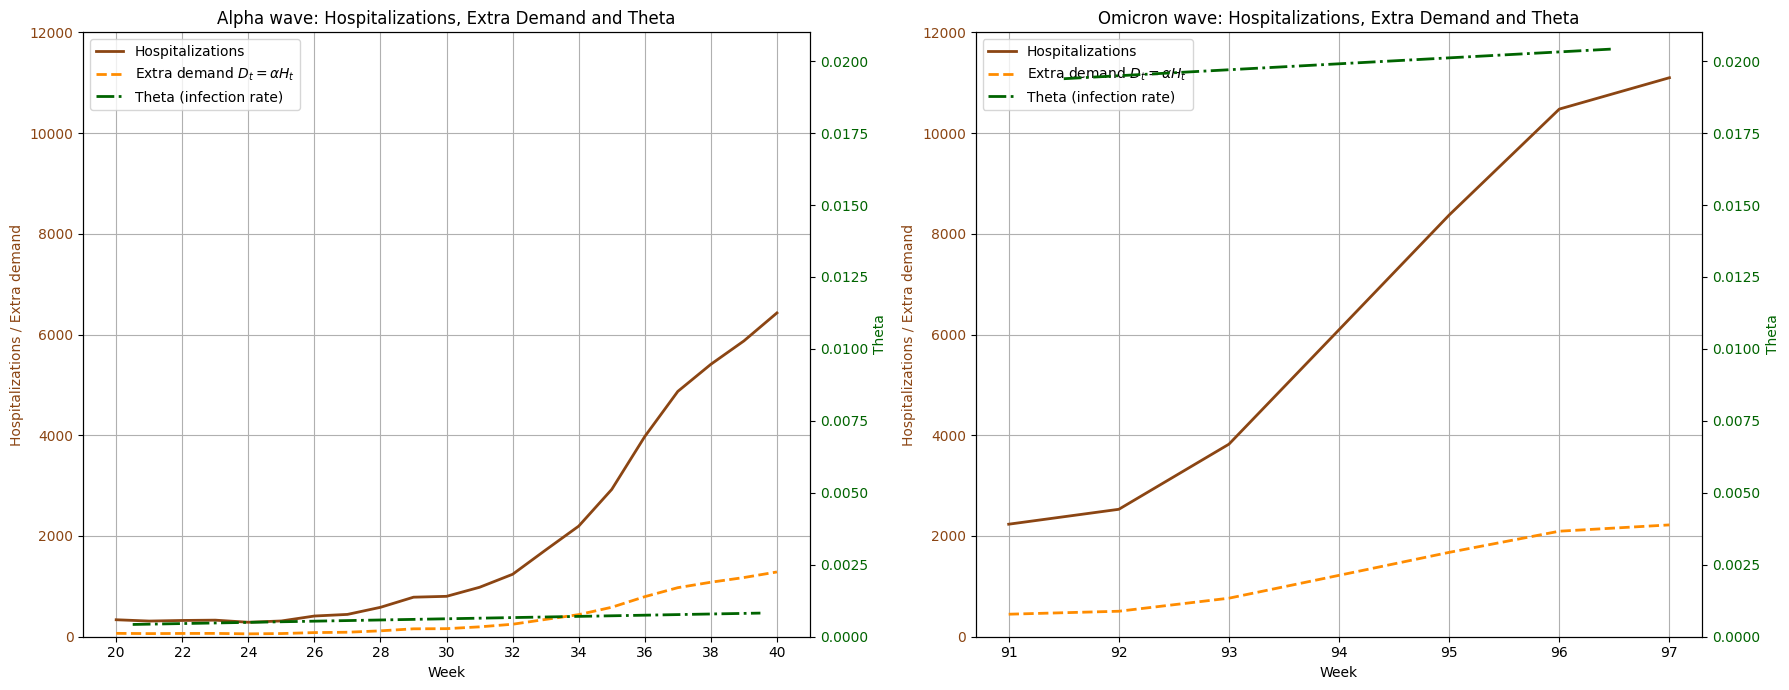

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

deep_green  = '#006400'   # theta
deep_orange = '#FF8C00'   # D
deep_brown  = '#8B4513'   # hospitalizations

left_ymin, left_ymax   = 0, 12000
right_ymin, right_ymax = 0, 0.021

alpha = 1/5

# ALPHA WAVE DATA (weeks 20–40)
weeks_1 = np.arange(20, 41)
hosp_20_40 = np.array([
    337, 311, 323, 329, 287, 313, 411,
    443, 584, 785, 802, 982, 1240, 1722,
    2196, 2925, 3975, 4871, 5409, 5873, 6429
])
D_1 = np.round(alpha * hosp_20_40).astype(int)

theta_1 = np.array([
    0.0004260515, 0.0004468345, 0.0004676175, 0.0004884005,
    0.0005091835, 0.0005299665, 0.0005507495, 0.0005715325,
    0.0005923155, 0.0006130985, 0.0006338815, 0.0006546645,
    0.0006754475, 0.0006962305, 0.0007170135, 0.0007377965,
    0.0007585795, 0.0007793625, 0.0008001455, 0.0008209285
])
theta_weeks_1 = weeks_1[:-1] + 0.5

# OMICRON WAVE DATA (weeks 91–97)
weeks_2 = np.arange(91, 98)
hosp_91_97 = np.array([2234, 2530, 3823, 6096, 8373, 10476, 11099])
D_2 = np.round(alpha * hosp_91_97).astype(int)

theta_2 = np.array([0.01938822, 0.01959590, 0.01980338,
                    0.02001006, 0.02021674, 0.02042342])
theta_weeks_2 = weeks_2[:-1] + 0.5

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# left: ALPHA wave
axL = ax1
axL.plot(weeks_1, hosp_20_40, linewidth=2, color=deep_brown,
         label="Hospitalizations")
axL.plot(weeks_1, D_1, '--', linewidth=2, color=deep_orange,
         label=r"Extra demand $D_t = \alpha H_t$")
axL.set_xlabel("Week")
axL.set_ylabel("Hospitalizations / Extra demand", color=deep_brown)
axL.tick_params(axis='y', labelcolor=deep_brown)
axL.set_ylim(left_ymin, left_ymax)
axL.set_title("Alpha wave: Hospitalizations, Extra Demand and Theta")

axL_r = axL.twinx()
axL_r.plot(theta_weeks_1, theta_1, '-.', linewidth=2, color=deep_green,
           label="Theta (infection rate)")
axL_r.set_ylabel("Theta", color=deep_green)
axL_r.tick_params(axis='y', labelcolor=deep_green)
axL_r.set_ylim(right_ymin, right_ymax)

lines_L = axL.get_lines() + axL_r.get_lines()
labels_L = [l.get_label() for l in lines_L]
axL.legend(lines_L, labels_L, loc="upper left")

axL.grid(True)
axL.set_xticks(np.arange(20, 41, 2))

# right: OMICRON wave
axR = ax2
axR.plot(weeks_2, hosp_91_97, linewidth=2, color=deep_brown,
         label="Hospitalizations")
axR.plot(weeks_2, D_2, '--', linewidth=2, color=deep_orange,
         label=r"Extra demand $D_t = \alpha H_t$")
axR.set_xlabel("Week")
axR.set_ylabel("Hospitalizations / Extra demand", color=deep_brown)
axR.tick_params(axis='y', labelcolor=deep_brown)
axR.set_ylim(left_ymin, left_ymax)
axR.set_title("Omicron wave: Hospitalizations, Extra Demand and Theta")

axR_r = axR.twinx()
axR_r.plot(theta_weeks_2, theta_2, '-.', linewidth=2, color=deep_green,
           label="Theta (infection rate)")
axR_r.set_ylabel("Theta", color=deep_green)
axR_r.tick_params(axis='y', labelcolor=deep_green)
axR_r.set_ylim(right_ymin, right_ymax)

lines_R = axR.get_lines() + axR_r.get_lines()
labels_R = [l.get_label() for l in lines_R]
axR.legend(lines_R, labels_R, loc="upper left")

axR.grid(True)
axR.set_xticks(np.arange(91, 98, 1))


plt.tight_layout()
plt.show()



ALPHA wave (weeks 20–40)
Week |   AS     I    AR      AO      AC     D    demand  backfill  redeploy  overtime
------------------------------------------------------------------------------------
  20 |  6776     0     0   19287    6776    67    6843        67         0        67
  21 |  6773     3     0   19287    6773    62    6838        65         0        65
  22 |  6770     5     1   19287    6771    65    6841        70         0        70
  23 |  6767     6     3   19287    6770    66    6842        72         0        72
  24 |  6764     7     5   19287    6769    57    6833        64         0        64
  25 |  6761     7     8   19287    6769    63    6839        70         0        70
  26 |  6757     8    11   19287    6768    82    6858        90         0        90
  27 |  6753     9    14   19287    6767    89    6865        98         0        98
  28 |  6749     9    18   19287    6767   117    6893       126         0       126
  29 |  6745     9    22   19287    67

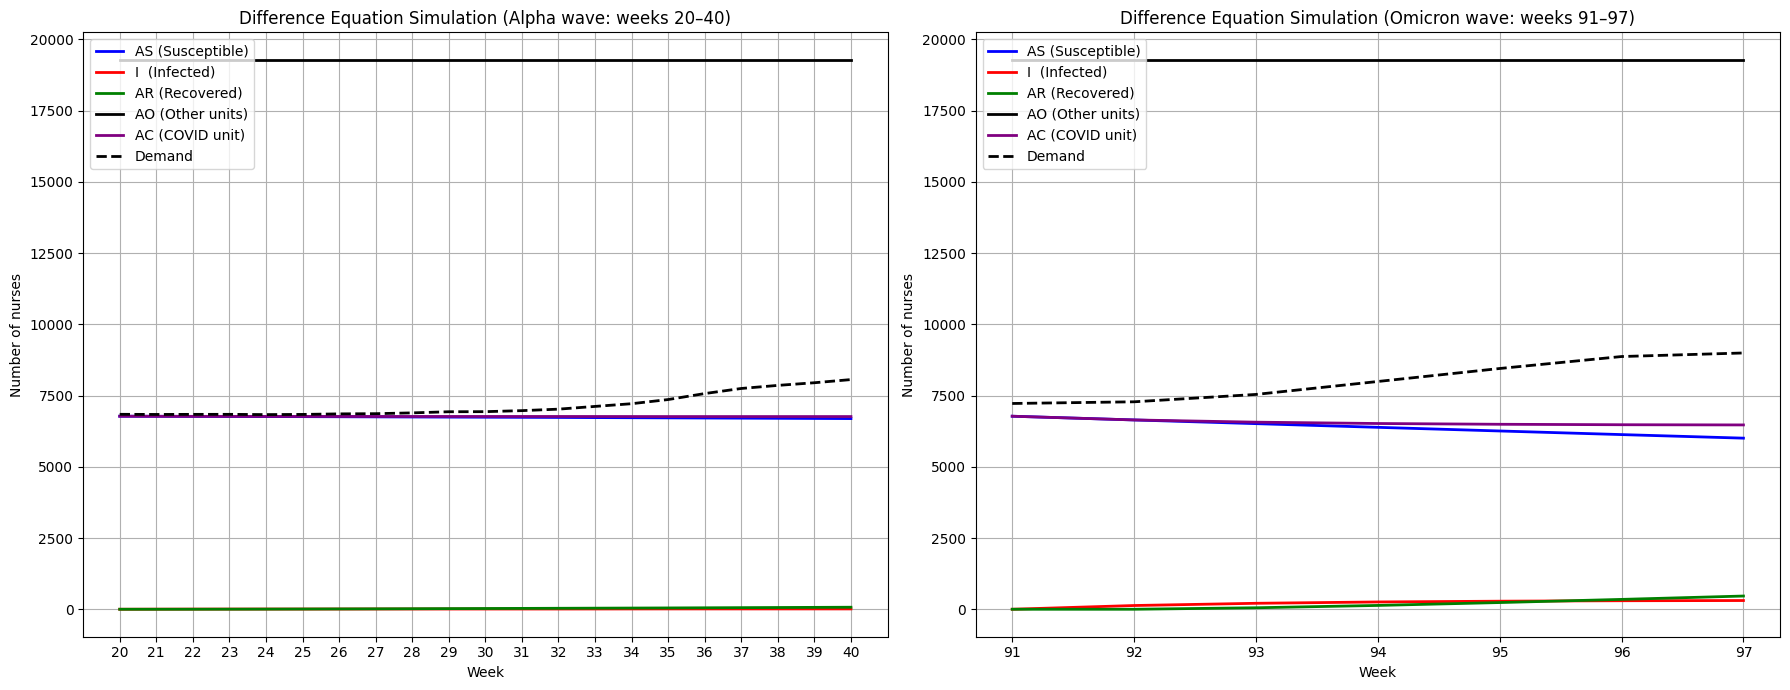

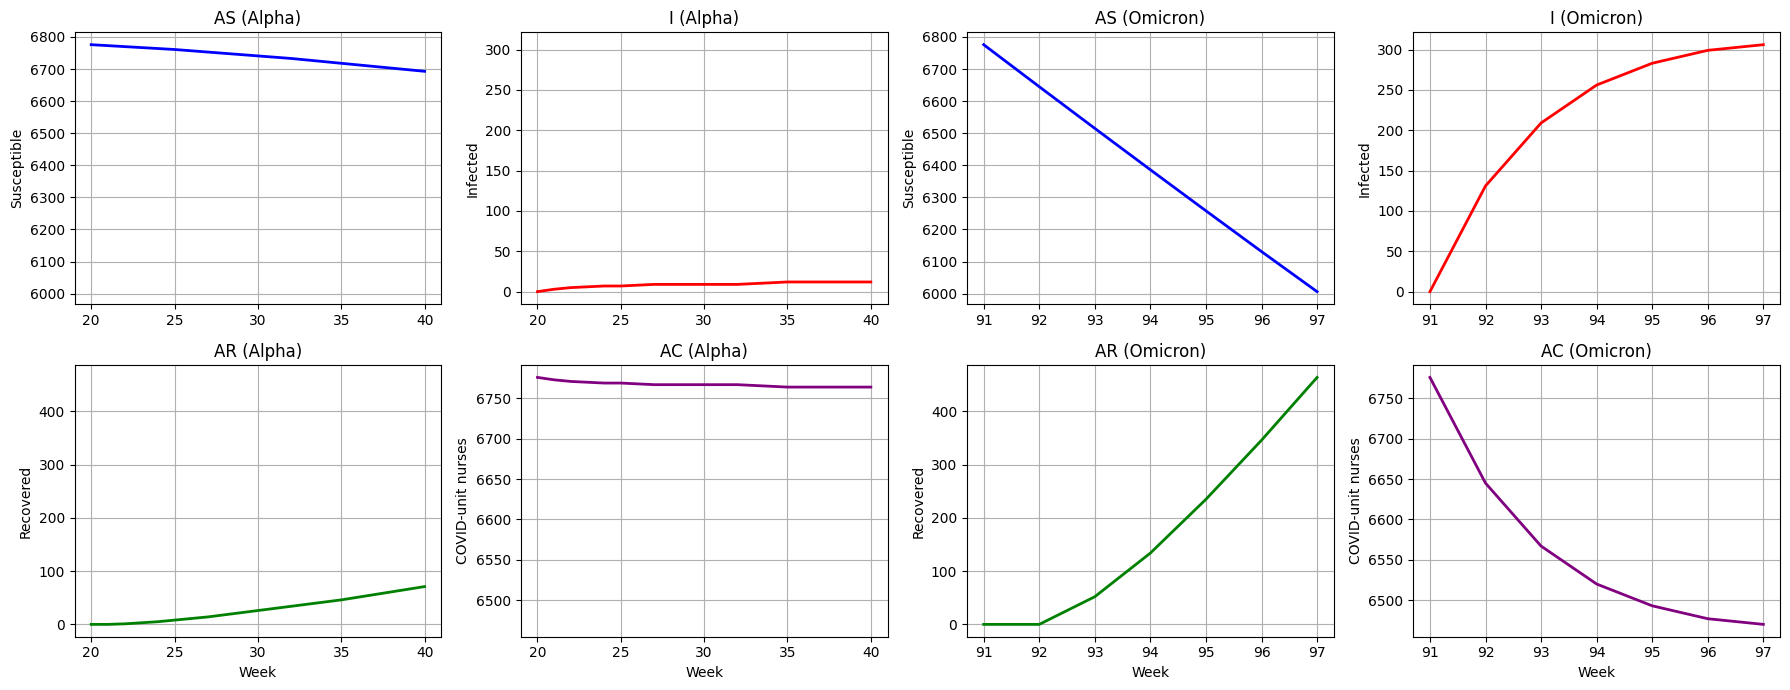

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS
gamma  = 1/2.0              # recovery rate (per week)
dt     = 1.0                # time step = 1 week
Amax   = int(38900 * 0.67)  # total ACTIVE nurses (constant)
alpha  = 1/5                # nurse–to-patient ratio
fracC0 = 0.26               # initial fraction in COVID unit
p      = 0                  # fraction of backfill from redeployment (0, 0.5, 1)

# SIMULATION FUNCTION
def simulate_wave(name, week_start, hosp, theta, p, fracC0=0.26):
    """
    hosp  : array of weekly hospitalizations (length N)
    theta : array of infection risks per interval (length N-1)
    """
    N = len(hosp)

    # demand from hospitalizations
    D = np.round(alpha * hosp).astype(int)

    AS = np.zeros(N, dtype=int)   # susceptible in COVID unit
    I  = np.zeros(N, dtype=int)   # infected
    AR = np.zeros(N, dtype=int)   # recovered in COVID unit
    AO = np.zeros(N, dtype=int)   # active in other units
    AC = np.zeros(N, dtype=int)   # active in COVID unit (S + R)

    demand   = np.zeros(N, dtype=int)
    backfill = np.zeros(N, dtype=int)
    redeploy = np.zeros(N, dtype=int)
    overtime = np.zeros(N, dtype=int)
    new_inf  = np.zeros(N, dtype=int)
    ret      = np.zeros(N, dtype=int)

    # initial conditions
    AC0 = int(round(fracC0 * Amax))   # initial COVID-unit active nurses
    AO0 = Amax - AC0                  # initial nurses in other units

    AS[0] = AC0  # I0 = AR0 = 0 --> AS0 = AC0
    I[0]  = 0
    AR[0] = 0
    AO[0] = AO0
    AC[0] = AS[0] + AR[0]

    AS0 = AS[0]  # baseline for demand = AS0 + D

    demand[0]   = AS0 + D[0]
    backfill[0] = max(demand[0] - AC[0], 0)

    weeks = np.arange(week_start, week_start + N)

    for n in range(N - 1):

        # current active in COVID unit
        AC[n] = AS[n] + AR[n]

        # demand at week n
        demand[n] = AS0 + D[n]

        # gap
        bf = max(demand[n] - AC[n], 0)
        backfill[n] = bf

        # redeployment from other units
        redep_float = min(AO[n], p * bf)
        redeploy[n] = int(round(redep_float))

        # overtime fills the remaining gap
        overtime_float = (1 - p) * bf
        overtime[n] = int(round(overtime_float))

        # new infections in COVID unit
        new_inf_float = min(AS[n], theta[n] * AS[n])
        new_inf[n] = int(round(new_inf_float))

        # return from infection (I --> AR)
        ret_float = (1 - np.exp(-gamma * dt)) * I[n]
        ret[n] = int(round(ret_float))

        # update states
        AS[n+1] = AS[n] - new_inf[n] + redeploy[n]
        I[n+1]  = I[n] + new_inf[n] - ret[n]
        AR[n+1] = AR[n] + ret[n]
        AO[n+1] = AO[n] - redeploy[n]
        AC[n+1] = AS[n+1] + AR[n+1]

    AC[-1]       = AS[-1] + AR[-1]
    demand[-1]   = AS0 + D[-1]
    backfill[-1] = max(demand[-1] - AC[-1], 0)

    print(f"\n{name}")
    print("Week |   AS     I    AR      AO      AC     D    demand  backfill  redeploy  overtime")
    print("------------------------------------------------------------------------------------")
    for i in range(N):
        print(f"{weeks[i]:4d} | {AS[i]:5d} {I[i]:5d} {AR[i]:5d} {AO[i]:7d} {AC[i]:7d} "
              f"{D[i]:5d} {demand[i]:7d} {backfill[i]:9d} {redeploy[i]:9d} {overtime[i]:9d}")

    return {
        "weeks":    weeks,
        "AS":       AS,
        "I":        I,
        "AR":       AR,
        "AO":       AO,
        "AC":       AC,
        "D":        D,
        "demand":   demand,
        "backfill": backfill,
        "redeploy": redeploy,
        "overtime": overtime,
        "new_inf":  new_inf,
        "ret":      ret,
    }

# ALPHA WAVE DATA (weeks 20–40)
hosp_20_40 = np.array([
    337, 311, 323, 329, 287, 313, 411,
    443, 584, 785, 802, 982, 1240, 1722,
    2196, 2925, 3975, 4871, 5409, 5873, 6429
])

theta_1 = np.array([
    0.0004260515, 0.0004468345, 0.0004676175, 0.0004884005,
    0.0005091835, 0.0005299665, 0.0005507495, 0.0005715325,
    0.0005923155, 0.0006130985, 0.0006338815, 0.0006546645,
    0.0006754475, 0.0006962305, 0.0007170135, 0.0007377965,
    0.0007585795, 0.0007793625, 0.0008001455, 0.0008209285
])  # length 20 = N-1

res1 = simulate_wave("ALPHA wave (weeks 20–40)", 20, hosp_20_40, theta_1, p)

# OMICRON WAVE DATA (weeks 91–97)
hosp_91_97 = np.array([2234, 2530, 3823, 6096, 8373, 10476, 11099])

theta_2 = np.array([
    0.01938822, 0.01959590, 0.01980338,
    0.02001006, 0.02021674, 0.02042342
])  # length 6 = N-1

res2 = simulate_wave("OMICRON wave (weeks 91–97)", 91, hosp_91_97, theta_2, p)

# PLOT 1: OVERVIEW
weeks1  = res1["weeks"]
AS1     = res1["AS"]
I1      = res1["I"]
AR1     = res1["AR"]
AO1     = res1["AO"]
AC1     = res1["AC"]
demand1 = res1["demand"]

weeks2  = res2["weeks"]
AS2     = res2["AS"]
I2      = res2["I"]
AR2     = res2["AR"]
AO2     = res2["AO"]
AC2     = res2["AC"]
demand2 = res2["demand"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(18, 7))

# left: ALPHA wave
axL.plot(weeks1, AS1, color='blue',   linewidth=2, label='AS (Susceptible)')
axL.plot(weeks1, I1,  color='red',    linewidth=2, label='I  (Infected)')
axL.plot(weeks1, AR1, color='green',  linewidth=2, label='AR (Recovered)')
axL.plot(weeks1, AO1, color='black',  linewidth=2, label='AO (Other units)')
axL.plot(weeks1, AC1, color='purple', linewidth=2, label='AC (COVID unit)')
axL.plot(weeks1, demand1, 'k--',      linewidth=2, label='Demand')

axL.set_title('Difference Equation Simulation (Alpha wave: weeks 20–40)')
axL.set_xlabel('Week')
axL.set_ylabel('Number of nurses')
axL.grid(True)
axL.legend(loc='upper left')
axL.set_xticks(np.arange(20, 41, 1))

# right: OMICRON wave
axR.plot(weeks2, AS2, color='blue',   linewidth=2, label='AS (Susceptible)')
axR.plot(weeks2, I2,  color='red',    linewidth=2, label='I  (Infected)')
axR.plot(weeks2, AR2, color='green',  linewidth=2, label='AR (Recovered)')
axR.plot(weeks2, AO2, color='black',  linewidth=2, label='AO (Other units)')
axR.plot(weeks2, AC2, color='purple', linewidth=2, label='AC (COVID unit)')
axR.plot(weeks2, demand2, 'k--',      linewidth=2, label='Demand')

axR.set_title('Difference Equation Simulation (Omicron wave: weeks 91–97)')
axR.set_xlabel('Week')
axR.set_ylabel('Number of nurses')
axR.grid(True)
axR.legend(loc='upper left')
axR.set_xticks(np.arange(91, 98, 1))

all_vals1 = np.concatenate([AS1, I1, AR1, AO1, AC1, demand1])
all_vals2 = np.concatenate([AS2, I2, AR2, AO2, AC2, demand2])
ymin = min(all_vals1.min(), all_vals2.min())
ymax = max(all_vals1.max(), all_vals2.max())
pad  = 0.05 * (ymax - ymin)
axL.set_ylim(ymin - pad, ymax + pad)
axR.set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
plt.show()

# PLOT 2: SUBPLOTS
fig, axs = plt.subplots(2, 4, figsize=(18, 7))

def set_shared_ylim(ax_a, ax_b, s1, s2, pad_ratio=0.05):
    ymin = min(s1.min(), s2.min())
    ymax = max(s1.max(), s2.max())
    pad  = pad_ratio * (ymax - ymin if ymax > ymin else 1.0)
    ax_a.set_ylim(ymin - pad, ymax + pad)
    ax_b.set_ylim(ymin - pad, ymax + pad)

# left: ALPHA wave
axs[0, 0].plot(weeks1, AS1, color='blue', linewidth=2)
axs[0, 0].set_title('AS (Alpha)')
axs[0, 0].set_ylabel('Susceptible')
axs[0, 0].grid(True)
axs[0, 0].set_xticks(np.arange(20, 41, 5))

axs[0, 1].plot(weeks1, I1, color='red', linewidth=2)
axs[0, 1].set_title('I (Alpha)')
axs[0, 1].set_ylabel('Infected')
axs[0, 1].grid(True)
axs[0, 1].set_xticks(np.arange(20, 41, 5))

axs[1, 0].plot(weeks1, AR1, color='green', linewidth=2)
axs[1, 0].set_title('AR (Alpha)')
axs[1, 0].set_ylabel('Recovered')
axs[1, 0].set_xlabel('Week')
axs[1, 0].grid(True)
axs[1, 0].set_xticks(np.arange(20, 41, 5))

axs[1, 1].plot(weeks1, AC1, color='purple', linewidth=2)
axs[1, 1].set_title('AC (Alpha)')
axs[1, 1].set_ylabel('COVID-unit nurses')
axs[1, 1].set_xlabel('Week')
axs[1, 1].grid(True)
axs[1, 1].set_xticks(np.arange(20, 41, 5))

# right: OMICRON wave
axs[0, 2].plot(weeks2, AS2, color='blue', linewidth=2)
axs[0, 2].set_title('AS (Omicron)')
axs[0, 2].set_ylabel('Susceptible')
axs[0, 2].grid(True)
axs[0, 2].set_xticks(np.arange(91, 98, 1))

axs[0, 3].plot(weeks2, I2, color='red', linewidth=2)
axs[0, 3].set_title('I (Omicron)')
axs[0, 3].set_ylabel('Infected')
axs[0, 3].grid(True)
axs[0, 3].set_xticks(np.arange(91, 98, 1))

axs[1, 2].plot(weeks2, AR2, color='green', linewidth=2)
axs[1, 2].set_title('AR (Omicron)')
axs[1, 2].set_ylabel('Recovered')
axs[1, 2].set_xlabel('Week')
axs[1, 2].grid(True)
axs[1, 2].set_xticks(np.arange(91, 98, 1))

axs[1, 3].plot(weeks2, AC2, color='purple', linewidth=2)
axs[1, 3].set_title('AC (Omicron)')
axs[1, 3].set_ylabel('COVID-unit nurses')
axs[1, 3].set_xlabel('Week')
axs[1, 3].grid(True)
axs[1, 3].set_xticks(np.arange(91, 98, 1))

set_shared_ylim(axs[0, 0], axs[0, 2], AS1, AS2)   # AS
set_shared_ylim(axs[0, 1], axs[0, 3], I1,  I2)    # I
set_shared_ylim(axs[1, 0], axs[1, 2], AR1, AR2)   # AR
set_shared_ylim(axs[1, 1], axs[1, 3], AC1, AC2)   # AC

plt.tight_layout()
plt.show()
